# Анализ результатов А/В-теста: увеличение конверсии в покупку для интернет-магазина

- Автор: Березинский Вадим Сергеевич
- Дата: 14.06.2025

### Цели и задачи проекта

**Цель исследования:** проанализировать результаты А/В-теста интернет-магазина и проверить гипотезу о том, что новая платёжная воронка увеличивает конверсию в покупку.

**Задачи:**
1. Провести предобработку данных.
2. Провести предварительную проверку результатов А/В-теста:
    - Проверить равномерность распределения в выборках.
    - Подготовить датафрейм для расчетов
    - Проверить сопоставимость выборок.
3. Анализ результатов А/В-теста:
   - Рассчитать конверсию в покупку по дням эксперимента.
   - Рассчитать общую конверсию в покупку
   - Рассчитать средний чек
   - Проверить статистическую значимость полученных результатов.
4. Сформулировать выводы по проведённому анализу.

### Описание данных

Анализ проводится на основе следующих наборов данных:

Таблица `new_users_test_2025.csv` состоит из полей:

    - `user_id` — уникальный идентификатор пользователя;

    - `first_date` — дата регистрации;

    - `region` — регион, к которому относится пользователь;

    - `device` — устройство, с которого происходила регистрация.
    
Таблица `sessions_test_2025.csv` состоит из полей:

    - `user_id` — уникальный идентификатор пользователя;

    - `session_start` — дата начала сессии;

    - `session_duration` — длительность сессии в минутах.
    
Таблица `purchases_test_2025.csv` состоит из полей:

    - `user_id` — уникальный идентификатор пользователя;

    - `event_dt` — дата и время покупки;

    - `revenue` — стоимость покупки в долларах.
    
Таблица `participants_test_2025.csv` состоит из полей:

    - `user_id` — уникальный идентификатор пользователя;

    - `group` — группа А/B-теста;

    - `ab_test` — название А/B-теста.

### Предварительная обработка данных

Загрузим данные из таблиц и познакомимся с ними.

In [5]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеки для статистических расчетов
import scipy.stats as st
import numpy as np

In [6]:
# Запишем csv-файлы в переменные:

new_users = pd.read_csv('new_users_test_2025.csv')
sessions = pd.read_csv('sessions_test_2025.csv')
purchases = pd.read_csv('purchases_test_2025.csv')
participants = pd.read_csv('participants_test_2025.csv')

# Создаем список для хранения датафреймов:

dfs = [new_users,sessions,purchases,participants]

# Запускаем цикл для просмотра датафреймов:

for df in dfs:
    display(df.head())
    display(df.info())
    print('********************')

,user_id,first_date,region,device
0,D72A72121175D8BE,2025-06-01,South Asia,iPhone
1,F1C668619DFE6E65,2025-06-01,Southeast Asia,iPhone
2,2E1BF1D4C37EA01F,2025-06-01,Central Asia,Mac
3,50734A22C0C63768,2025-06-01,Central Asia,Android
4,E1BDDCE0DAFA2679,2025-06-01,Southeast Asia,iPhone


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131486 entries, 0 to 131485
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   user_id     131486 non-null  object
 1   first_date  131486 non-null  object
 2   region      131486 non-null  object
 3   device      131486 non-null  object
dtypes: object(4)
memory usage: 4.0+ MB


None

********************


,user_id,session_start,session_duration
0,D72A72121175D8BE,2025-06-01 05:51:20,1.0
1,F1C668619DFE6E65,2025-06-01 15:28:14,5.0
2,2E1BF1D4C37EA01F,2025-06-01 16:19:36,3.0
3,50734A22C0C63768,2025-06-01 21:06:51,1.0
4,E1BDDCE0DAFA2679,2025-06-01 10:03:00,2.0


...

********************


,user_id,group,ab_test
0,6A8825D752FCFFB6,A,new_payment_funnel_test_summer_2025
1,0B75608CBBA59791,B,new_payment_funnel_test_summer_2025
2,6B9D2F7685B83C73,A,new_payment_funnel_test_summer_2025
3,6435D4C2E66A7F75,B,new_payment_funnel_test_summer_2025
4,4F815438BBD2BB7E,A,new_payment_funnel_test_summer_2025


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3291 entries, 0 to 3290
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  3291 non-null   object
 1   group    3291 non-null   object
 2   ab_test  3291 non-null   object
dtypes: object(3)
memory usage: 77.3+ KB


None

********************


In [7]:
# Проверим датафреймы на наличие полных дубликатов:

user_duplicates = new_users.duplicated()
user_num_duplicates = user_duplicates.sum()
print(f"Количество полных дубликатов в таблице `new_users`: {user_num_duplicates}")

session_duplicates = sessions.duplicated()
session_num_duplicates = session_duplicates.sum()
print(f"Количество полных дубликатов в таблице `sessions`: {session_num_duplicates}")

purchase_duplicates = purchases.duplicated()
purchase_num_duplicates = purchase_duplicates.sum()
print(f"Количество полных дубликатов в таблице `purchases`: {purchase_num_duplicates}")

participant_duplicates = participants.duplicated()
participant_num_duplicates = participant_duplicates.sum()
print(f"Количество полных дубликатов в таблице `participants`: {participant_num_duplicates}")

Количество полных дубликатов в таблице `new_users`: 0
Количество полных дубликатов в таблице `sessions`: 0
Количество полных дубликатов в таблице `purchases`: 0
Количество полных дубликатов в таблице `participants`: 0


In [8]:
new_users['user_id'].duplicated().sum()

0

In [9]:
sessions[['user_id','session_start']].duplicated().sum()

0

**Промежуточный вывод**

Данные загружены корректно, содержимое таблиц соответствует описанию. Наименования столбцов корректные, не требуют нормализации.

Таблица `new_users` содержит 131486 строк и 4 столбца, пропуски в данных отсутствуют. Столбец `first_date` одержит данные о дате и требует приведения к формату даты.

Таблица `sessions` содержит 491443 строк и 3 столбца, пропуски в данных отсутствуют. Столбец `session_start` одержит данные о дате и времени и требует приведения к формату даты.

Таблица `purchases` содержит 149152 строк и 3 столбца, пропуски в данных отсутствуют. Столбец `event_dt` одержит данные о дате и времени и требует приведения к формату даты.

Таблица `participants` содержит 3291 строк и 3 столбца, пропуски в данных отсутствуют, типы данных выбраны корректно.

Полные дубликаты в датафреймах не выявлены.

In [11]:
# Приведем данные о дате и времени в формат даты:

new_users['first_date'] = pd.to_datetime(new_users['first_date']).dt.date

sessions['session_start'] = pd.to_datetime(sessions['session_start'])

purchases['event_dt'] = pd.to_datetime(purchases['event_dt'])

In [12]:
for df in dfs:
    display(df.info())
    print('********************')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131486 entries, 0 to 131485
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   user_id     131486 non-null  object
 1   first_date  131486 non-null  object
 2   region      131486 non-null  object
 3   device      131486 non-null  object
dtypes: object(4)
memory usage: 4.0+ MB


None

********************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491443 entries, 0 to 491442
Data columns (total 3 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   user_id           491443 non-null  object        
 1   session_start     491443 non-null  datetime64[ns]
 2   session_duration  491443 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 11.2+ MB


None

********************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149152 entries, 0 to 149151
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   user_id   149152 non-null  object        
 1   event_dt  149152 non-null  datetime64[ns]
 2   revenue   149152 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 3.4+ MB


None

********************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3291 entries, 0 to 3290
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  3291 non-null   object
 1   group    3291 non-null   object
 2   ab_test  3291 non-null   object
dtypes: object(3)
memory usage: 77.3+ KB


None

********************


Данные о дате и времени приведены к формату даты или даты-времени.

## Предварительная проверка результатов А/В-теста

#### Проверка распределения пользователей

Сформируем группы участников теста, проверим их на равномерность и пересечения.

In [16]:
# Обединим датафрейм участников с датафреймом новых пользователей, чтобы получить информацию о регионе и девайсе:

participants = participants.merge(new_users, how='inner',on='user_id')

display(participants.head())

,user_id,group,ab_test,first_date,region,device
0,6A8825D752FCFFB6,A,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,Android
1,0B75608CBBA59791,B,new_payment_funnel_test_summer_2025,2025-06-14,Southeast Asia,Android
2,6B9D2F7685B83C73,A,new_payment_funnel_test_summer_2025,2025-06-08,Southeast Asia,Mac
3,6435D4C2E66A7F75,B,new_payment_funnel_test_summer_2025,2025-06-13,Southeast Asia,Android
4,4F815438BBD2BB7E,A,new_payment_funnel_test_summer_2025,2025-06-07,Southeast Asia,Android


In [17]:
# Проверим размер выборок в группах А и В:

a_group_count = participants[(participants['ab_test']=='new_payment_funnel_test_summer_2025')&(participants['group']=='A')]['user_id'].nunique()

b_group_count = participants[(participants['ab_test']=='new_payment_funnel_test_summer_2025')&(participants['group']=='B')]['user_id'].nunique()

display(f'Количество уникальных пользователей составляет: в группе А - {a_group_count} человек, в группе В - {b_group_count} человек.')

'Количество уникальных пользователей составляет: в группе А - 1598 человек, в группе В - 1468 человек.'

In [18]:
# Посчитаем процентную разницу в количестве пользователей в группах A и B:

dif_ab_count=round(((a_group_count-b_group_count)/a_group_count)*100,1)

display(f'Процентная разница в количестве пользователей в группах A и B составляет {dif_ab_count}%.')

'Процентная разница в количестве пользователей в группах A и B составляет 8.1%.'

В группу В попало на 8.1% пользователей больше, чем в группу А.

In [20]:
# Зададим множество пользователей из группы А:

a_group = set(participants[(participants['ab_test']=='new_payment_funnel_test_summer_2025')&(participants['group']=='A')]['user_id'])

# Зададим множество пользователей из группы В:

b_group = set(participants[(participants['ab_test']=='new_payment_funnel_test_summer_2025')&(participants['group']=='B')]['user_id'])

# Найдем пересечение множеств:

intersection = a_group.intersection(b_group)

if intersection == set():
    display('Группы A и B не пересекаются.')
else:
    display(f'Группы A и B включают одинаковых пользователей:{intersection}')

'Группы A и B не пересекаются.'

Убедимся в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройства и регионам.

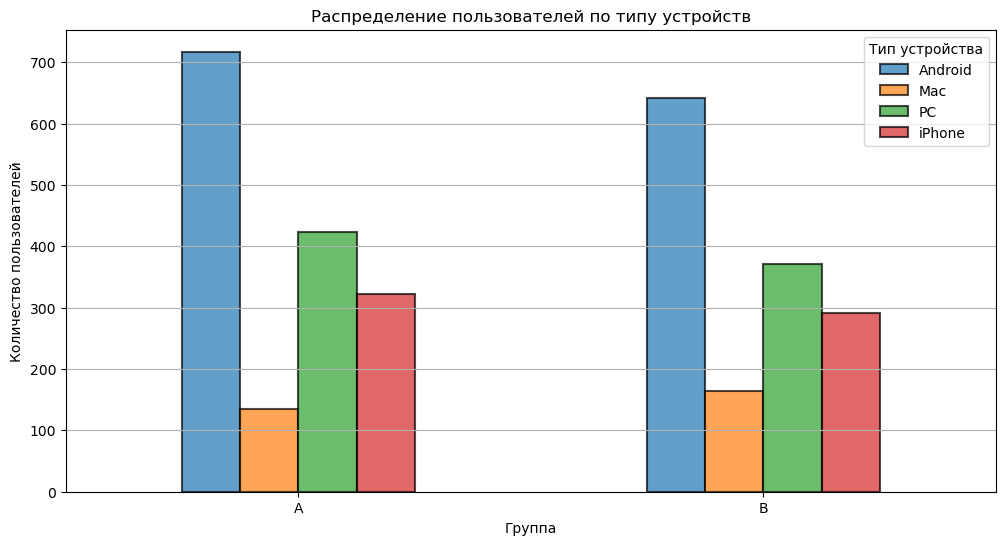

In [22]:
participants[participants['ab_test']=='new_payment_funnel_test_summer_2025'].groupby(['group','device'])['user_id'].nunique().unstack().plot(kind='bar',
                                                                                        figsize=(12,6),
                                                                                        edgecolor='black', 
                                                                                        linewidth=1.5, 
                                                                                        alpha=0.7,
                                                                                        rot=0)

plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей по типу устройств')
plt.legend(title='Тип устройства')
plt.grid(axis='y')
plt.show()

**Из графика распределения пользователей по типу устройств видно, что в целом группы А и В равнмерно распределены по типу используемых пользователями устройств (в группе В немного больше пользователей, испольующих Mac, и немного меньше пользователей, использующих другие категории устройств), что позволяет нам продолжать проверку результатов эксперимента.**

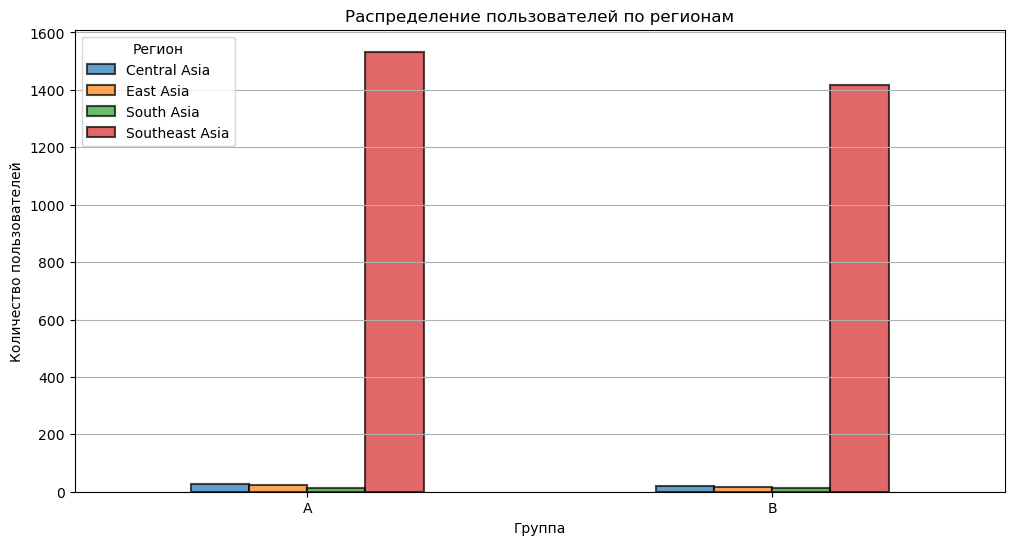

In [24]:
participants[participants['ab_test']=='new_payment_funnel_test_summer_2025'].groupby(['group','region'])['user_id'].nunique().unstack().plot(kind='bar',
                                                                                        figsize=(12,6),
                                                                                        edgecolor='black', 
                                                                                        linewidth=1.5, 
                                                                                        alpha=0.7,
                                                                                        rot=0)

plt.xlabel('Группа')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей по регионам')
plt.legend(title='Регион')
plt.grid(axis='y')
plt.show()

**Из графика распределения пользователей по регионам видно, что в целом группы А и В равномерно распределены по регионам (в обеих группах преобладает Центральная Азия), что позволяет нам продолжать проверку результатов эксперимента.**

#### Промежуточный вывод

В ходе мониторинга А/В-теста установили, что количество уникальных пользователей составляет:в группе А - 1598 человек, в группе В - 1468 человек, процентная разница в количестве пользователей в группах A и B составляет 8.1%. В целом разница по количеству пользователей в группах эксперимента присутствует, но поскольку группы сформированы случайным образом, то небольшая разница в размере выборок (около 8%) вполне допустима и не должна существенно влиять на результаты.

Группы A и B не пересекаются, то есть выборки являются независимыми, что позволяет нам продолжать проверку результатов эксперимента.

При построении графиков мы видим, что пользователи в целом равномерно распределены по всем доступным категориальным переменным — типам устройства и регионам, что позволяет нам продолжать проверку результатов эксперимента.

#### Подготовка датафрейма для расчетов

Создадим единый датафрейм. Поскольку мы будем изучать конверсию из пользователей в покупатели, то за основу возьмем таблицу `sessions`: мы будем исследовать, сколько сессий завершилось покупкой. К таблице с сессиями по левому типу присоединим последовательно три других датафрейма: из таблицы с пользователями получим дату регистрации, тип устойства и регион, из таблицы с покупками получим дату и сумму покупки, из таблицы с участниками тестировани полуим сведения об участии в тесте и принадлежности к тестовой группе.

In [28]:
df = sessions.merge(participants, how='inner',on='user_id')

df = df.merge(purchases, how='left',left_on=['user_id','session_start'],right_on=['user_id','event_dt'])

df.head()

,user_id,session_start,session_duration,group,ab_test,first_date,region,device,event_dt,revenue
0,8942E64218C9A1ED,2025-06-01 15:37:04,3.54,B,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,Android,NaT,NaN
1,5DFA5DCA1EAB4A61,2025-06-01 18:54:09,1.54,A,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,iPhone,NaT,NaN
2,76C343AEDA28AF61,2025-06-01 03:34:38,5.54,B,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,Android,2025-06-01 03:34:38,4.99
3,C0D574D58B8BEFC2,2025-06-01 19:59:21,3.08,A,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,Android,2025-06-01 19:59:21,4.99
4,95AB4B08CCDF772D,2025-06-01 16:27:45,3.54,B,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,iPhone,NaT,NaN


Допонительно выделим новый столбец с датой на основе столбца с датой и временем сессии `session_start`.

In [30]:
df['date'] = df['session_start'].dt.normalize()

df.head()

,user_id,session_start,session_duration,group,ab_test,first_date,region,device,event_dt,revenue,date
0,8942E64218C9A1ED,2025-06-01 15:37:04,3.54,B,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,Android,NaT,NaN,2025-06-01
1,5DFA5DCA1EAB4A61,2025-06-01 18:54:09,1.54,A,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,iPhone,NaT,NaN,2025-06-01
2,76C343AEDA28AF61,2025-06-01 03:34:38,5.54,B,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,Android,2025-06-01 03:34:38,4.99,2025-06-01
3,C0D574D58B8BEFC2,2025-06-01 19:59:21,3.08,A,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,Android,2025-06-01 19:59:21,4.99,2025-06-01
4,95AB4B08CCDF772D,2025-06-01 16:27:45,3.54,B,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,iPhone,NaT,NaN,2025-06-01


Отфильтруем датасет, оставив только данные по участникам эксперимента:

In [32]:
df = df[df['ab_test']=='new_payment_funnel_test_summer_2025']

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11321 entries, 0 to 12208
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           11321 non-null  object        
 1   session_start     11321 non-null  datetime64[ns]
 2   session_duration  11321 non-null  float64       
 3   group             11321 non-null  object        
 4   ab_test           11321 non-null  object        
 5   first_date        11321 non-null  object        
 6   region            11321 non-null  object        
 7   device            11321 non-null  object        
 8   event_dt          2566 non-null   datetime64[ns]
 9   revenue           2566 non-null   float64       
 10  date              11321 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), object(6)
memory usage: 1.0+ MB


In [34]:
df_duplicates = df.duplicated()
df_num_duplicates = df_duplicates.sum()
print(f"Количество полных дубликатов в таблице `df`: {df_num_duplicates}")

Количество полных дубликатов в таблице `df`: 0


В датафрейме получилось 11321 строк и 11 столбцов. 

#### Проверка сопоставимости полученных групп

Прежде чем приступать к анализу целевой продуктовой метрики, убедимся, что тест проведён корректно и мы будем сравнивать две сопоставимые группы. Рассчитаем количество уникальных сессий для каждого дня в обеих тестовых групп, используя группировку. Проверим, что количество уникальных сессий в двух выборках не различается или различия не статистически значимы. Для проверки используем статистический тест, который позволит сделать вывод о равенстве средних двух выборок.

In [37]:
# Сгруппируем данные о количестве сесиии для группы А:

a_session = df[df['group']=='A'].groupby(['date'])['session_start'].nunique().reset_index()['session_start']

display(a_session)

# Сгруппируем данные о количестве сесиии для группы B:

b_session = df[df['group']=='B'].groupby(['date'])['session_start'].nunique().reset_index()['session_start']

display(b_session)

0     166
1     190
2     194
3     187
4     227
5     254
6     322
7     387
8     320
9     249
10    306
11    288
12    327
13    397
14    315
15    225
16    194
17    162
18    128
19    145
20    100
21    112
22     97
23     74
24     94
25     81
26     82
27     79
28     81
29     11
Name: session_start, dtype: int64

0     161
1     178
2     164
3     194
4     220
5     248
6     299
7     341
8     329
9     278
10    312
11    287
12    314
13    369
14    240
15    191
16    161
17    165
18    132
19    116
20    118
21     96
22    107
23     88
24     76
25     94
26     62
27     75
28     76
29     15
Name: session_start, dtype: int64

Проверим, различается ли количество уникальных сессий в двух выборках.

Действовать будем по алгоритму проверки гипотез:

**1. Определяем тип гипотезы.** Нам необходимо проверить, что количество уникальных сессий в двух выборках не различается, то есть альтернативная гипотеза является двусторонней, поскольку нас интересует отклонение в любую сторону. 

**2. Формулируем нулевую и альтернативную гипотезы.**

Нулевая гипотеза(Н0): количество уникальных сессий в двух выборках не различается.

Альтернативная гипотеза (П1): количество уникальных сессий в двух выборках различается.

**3. Выбираем уровень значимости α**
Поскольку ситуация обычная и не требует повышенной осторожности, то выбираем уровень значимости α = 0.05

**4. Выбираем статистический тест для проверки гипотезы.** Поскольку у нас две выборки и вариативность данных в обеих выборках можно считать одинаковой, то для этих целей походит двухвыборочный t-тест Стьюдента.

In [39]:
import scipy.stats as st

# Запишем в переменную выбранное значение уровня значимости:

alpha = 0.05

# Проведем двухвыборочный t-тест Стьюдента:

results = st.ttest_ind(a_session,b_session,alternative='two-sided')

# Выведем р-значение:

print('p-значение:',results.pvalue)

# Проверим гипотезу, сравнив р-значение с уровнем значимости:

if results.pvalue<alpha:
    display('Отвергаем нулевую гипотезу. Количество уникальных дневных сессий в двух выборках различается.')
else:
    display('Не получилось отвергнуть нулевую гипотезу. Количество уникальных дневных сессий в двух выборках не различается.')

p-значение: 0.7145626690194112


'Не получилось отвергнуть нулевую гипотезу. Количество уникальных дневных сессий в двух выборках не различается.'

## Проверка результатов А/В-теста

**Определим метрики для эксперимента**

**Целевая метрика**

Команда продукта улучшила платежную воронку и ожидает, что это увеличит конверсию в покупку, следовательно целевой метрикой эксперимента необходимо выбрать конверсию посетителей приложения в покупателей - долю посетителей, совершибших покупку. Конверсия в покупку в группе, получившей доступ к новой воронке оплаты, должна быть больше, чем в группе, использующей старую версию приложения.

**Прокси-метрика**

Дополнительно к конверсии в покупку проверим поведение среднего чека покупки, поскольку улучшение платежной воронки может мотивировать покупателей совершать больше покупок.

**Барьерная метрика**

В данном эксперименте барьерной метрикой могла были доля возвратов, однако эти данные нам неизвестны, поэтому отслеживать барьерную метрику мы не будем.

#### Подсчет целевой метрики

Для расчета конверсии проведем группировку по дате, посчитаем конверсию в покупку для участников групп А и В.

In [41]:
# Сгруппируем данные о количестве сесиии и количестве покупок по дате для группы А:

a_conversion = df[df['group']=='A'].groupby(['date'])[['session_start','event_dt']].count().reset_index()

# Переименуем столбцы:

a_conversion.columns = ['date','session_count','purchase_count']

# Добавим новый столбец с конверсией в покупку:

a_conversion['conversion_to_purchase'] = (a_conversion['purchase_count'] / a_conversion['session_count']).round(2)

display(a_conversion)

,date,session_count,purchase_count,conversion_to_purchase
0,2025-06-01,166,44,0.27
1,2025-06-02,192,49,0.26
2,2025-06-03,194,38,0.20
3,2025-06-04,187,37,0.20
4,2025-06-05,228,71,0.31
5,2025-06-06,254,57,0.22
6,2025-06-07,322,58,0.18
7,2025-06-08,390,106,0.27
8,2025-06-09,322,96,0.30
9,2025-06-10,250,75,0.30


In [42]:
# Сгруппируем данные о количестве сесиии и количестве покупок по дате для группы В:

b_conversion = df[df['group']=='B'].groupby(['date'])[['session_start','event_dt']].count().reset_index()

# Переименуем столбцы:

b_conversion.columns = ['date','session_count','purchase_count']

# Добавим новый столбец с конверсией в покупку:

b_conversion['conversion_to_purchase'] = (b_conversion['purchase_count'] / b_conversion['session_count']).round(2)

display(b_conversion)

,date,session_count,purchase_count,conversion_to_purchase
0,2025-06-01,161,48,0.30
1,2025-06-02,178,46,0.26
2,2025-06-03,164,46,0.28
3,2025-06-04,194,52,0.27
4,2025-06-05,220,39,0.18
5,2025-06-06,249,45,0.18
6,2025-06-07,299,39,0.13
7,2025-06-08,341,40,0.12
8,2025-06-09,330,47,0.14
9,2025-06-10,278,46,0.17


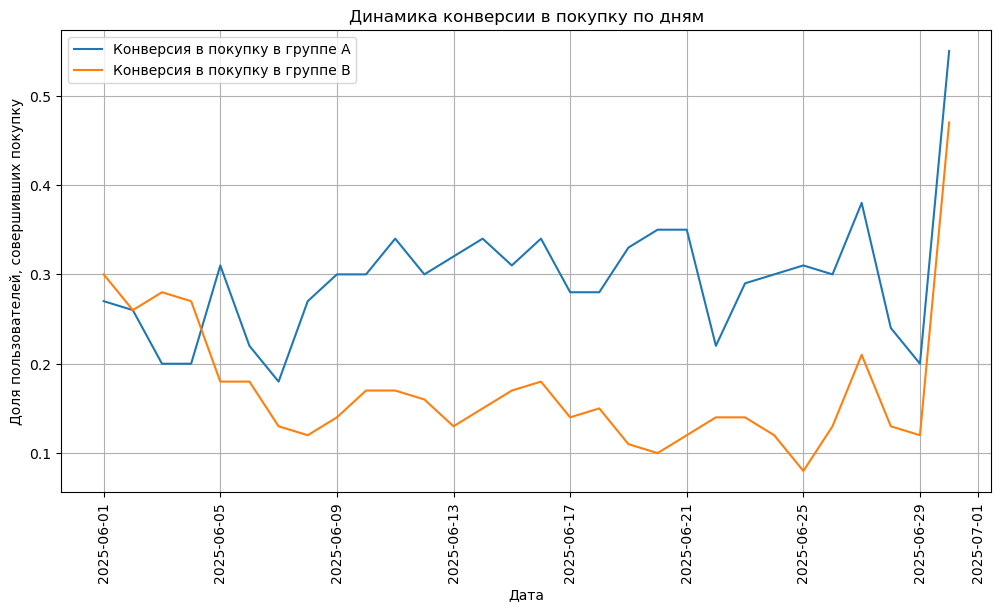

In [43]:
# Визуализируем метрику

# Зададим фигуру и ось:

fig, ax = plt.subplots(figsize=(12,6))

# Построим линию, отражающую изменение доли совершивших покупку по дням:

ax.plot(a_conversion['date'],a_conversion['conversion_to_purchase'],label='Конверсия в покупку в группе А')

ax.plot(b_conversion['date'],b_conversion['conversion_to_purchase'],label='Конверсия в покупку в группе B')

# Дадим название оси х:
ax.set_xlabel('Дата')

# Повернем значения по оси х на 90 градусов:
plt.xticks(rotation=90)

# Дадим название оси у:
ax.set_ylabel('Доля пользователей, совершивших покупку')

# Дадим название графику:
ax.set_title('Динамика конверсии в покупку по дням')

# Отобразим легенду:
ax.legend()

# Отобразим сетку:
ax.grid()

# Показываем график:
plt.show()

**Интерпретация**

Для каждой группы эксперимента мы выгрузили данные о количестве сессий по дням и количестве сессий, завершившихся покупкой, по дням. Нашли отношение количесва покупок к количеству сессиий (конверсию в покупку) и построили для каждой группы график конверсии. Мы видим, что вначале эксперимента конверсия в группе В превышала показатель группы А примерно на 8%, а затем снизилась и стабильно была ниже конверсии в группе А в среднем на 15%.

Теперь посчитаем общую за весь период эксперимента конверсию в покупку для групп А и В.

In [46]:
# Сгруппируем данные о количестве сесиии и количестве покупок по дате для группы В:

conversion = df.groupby(['group'])[['session_start','event_dt']].count().reset_index()

# Переименуем столбцы:

conversion.columns = ['group','session_count','purchase_count']

# Добавим новый столбец с конверсией в покупку:

conversion['conversion_to_purchase'] = (conversion['purchase_count'] / conversion['session_count']).round(2)

display(conversion)

,group,session_count,purchase_count,conversion_to_purchase
0,A,5806,1665,0.29
1,B,5515,901,0.16


In [47]:
diff_conversion = (conversion[conversion['group']=='A']['conversion_to_purchase'].iloc[0] - conversion[conversion['group']=='B']['conversion_to_purchase'].iloc[0])*100

display(f'Общая за весь период эксперимента конверсия в покупку в выборке A превышает этот показатель в выборке В на {diff_conversion:.0f}%')

'Общая за весь период эксперимента конверсия в покупку в выборке A превышает этот показатель в выборке В на 13%'

#### Подсчет прокси-метрики

Расчитаем средний чек в группах А и В

In [49]:
df.head()

,user_id,session_start,session_duration,group,ab_test,first_date,region,device,event_dt,revenue,date
0,8942E64218C9A1ED,2025-06-01 15:37:04,3.54,B,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,Android,NaT,NaN,2025-06-01
1,5DFA5DCA1EAB4A61,2025-06-01 18:54:09,1.54,A,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,iPhone,NaT,NaN,2025-06-01
2,76C343AEDA28AF61,2025-06-01 03:34:38,5.54,B,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,Android,2025-06-01 03:34:38,4.99,2025-06-01
3,C0D574D58B8BEFC2,2025-06-01 19:59:21,3.08,A,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,Android,2025-06-01 19:59:21,4.99,2025-06-01
4,95AB4B08CCDF772D,2025-06-01 16:27:45,3.54,B,new_payment_funnel_test_summer_2025,2025-06-01,Southeast Asia,iPhone,NaT,NaN,2025-06-01


In [50]:
# Рассчитаем средний чек по дням для группы А:

a_aov = df[df['group']=='A'].groupby(['date'])['revenue'].mean().round(2).reset_index()

display(a_aov)

# Рассчитаем средний чек по дням для группы B:

b_aov = df[df['group']=='B'].groupby(['date'])['revenue'].mean().round(2).reset_index()

display(b_aov)

,date,revenue
0,2025-06-01,37.04
1,2025-06-02,9.79
2,2025-06-03,19.33
3,2025-06-04,5.80
4,2025-06-05,41.40
5,2025-06-06,23.06
6,2025-06-07,24.13
7,2025-06-08,18.20
8,2025-06-09,47.54
9,2025-06-10,30.39


,date,revenue
0,2025-06-01,29.89
1,2025-06-02,15.86
2,2025-06-03,24.66
3,2025-06-04,35.86
4,2025-06-05,15.37
5,2025-06-06,34.21
6,2025-06-07,27.81
7,2025-06-08,7.86
8,2025-06-09,32.86
9,2025-06-10,33.14


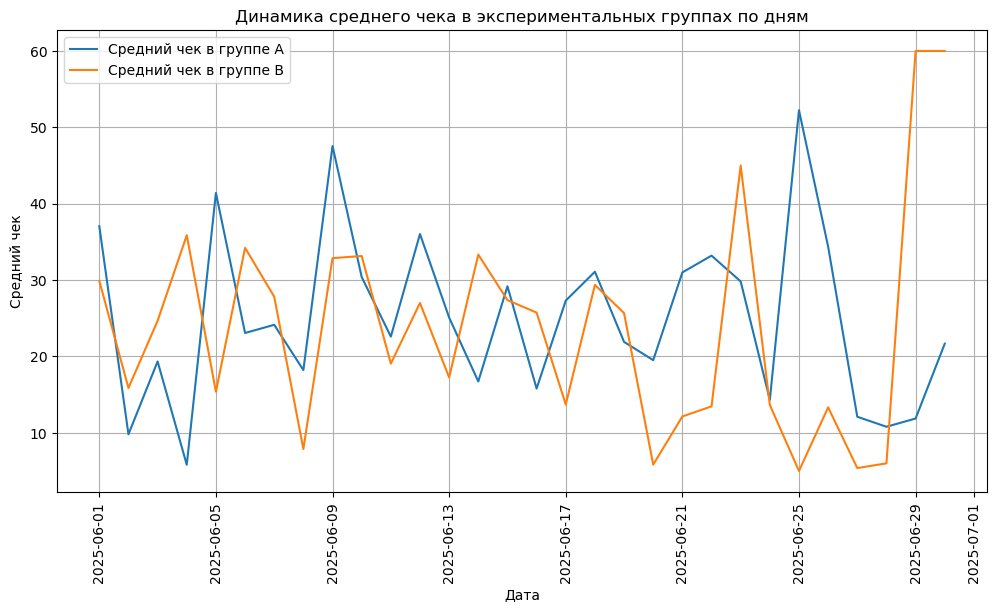

In [51]:
# Визуализируем метрику

# Зададим фигуру и ось:

fig, ax = plt.subplots(figsize=(12,6))

# Построим линию, отражающую изменение доли совершивших покупку по дням:

ax.plot(a_aov['date'],a_aov['revenue'],label='Средний чек в группе А')

ax.plot(b_aov['date'],b_aov['revenue'],label='Средний чек в группе B')

# Дадим название оси х:
ax.set_xlabel('Дата')

# Повернем значения по оси х на 90 градусов:
plt.xticks(rotation=90)

# Дадим название оси у:
ax.set_ylabel('Средний чек')

# Дадим название графику:
ax.set_title('Динамика среднего чека в экспериментальных группах по дням')

# Отобразим легенду:
ax.legend()

# Отобразим сетку:
ax.grid()

# Показываем график:
plt.show()

**Интерпретация**

Для каждой группы эксперимента мы выгрузили данные о среднем чеке по дням и построили для каждой группы график динамики среднего чека. График не позволяет нам однозначно выявить тенденции в динамике среднего чека по группам.

Сравним средний чек за весь период эксперимента.

In [53]:
aov = df.groupby(['group'])['revenue'].mean().round(2).reset_index()

display(aov)

,group,revenue
0,A,25.87
1,B,24.95


In [54]:
diff_aov = aov[aov['group']=='A']['revenue'].iloc[0] - aov[aov['group']=='B']['revenue'].iloc[0]

display(f'Средний чек в выборке A превышает этот показатель в выборке В на {diff_aov:.2f} доллара')

'Средний чек в выборке A превышает этот показатель в выборке В на 0.92 доллара'

### Проверка статистической значимости результатов

#### Проверим статистическую значимость изменения конверсии

Проверим, что общая за весь период эксперимента конверсия в покупку в группе В статистически ниже этого показателя в группе А.

Действовать будем по алгоритму проверки гипотез:

**1. Определяем тип гипотезы.** Нам необходимо проверить, что общая за весь период эксперимента конверсия в покупку в группе В статистически ниже этого показателя в группе А, то есть альтернативная гипотеза является односторонней, а именно - левосторонней, поскольку нас интересует отклонение в меньшую сторону. 

**2. Формулируем нулевую и альтернативную гипотезы.**

Нулевая гипотеза(Н0): конверсия в покупку в группе В равна конверсия в покупку в группе А.

Альтернативная гипотеза (П1): конверсия в покупку в группе В меньше конверсия в покупку в группе А.

**3. Выбираем уровень значимости α**
Поскольку ситуация обычная и не требует повышенной осторожности, то выбираем уровень значимости α = 0.05

**4. Выбираем статистический тест для проверки гипотезы.** Поскольку мы сравниваем вероятность успеха (конверсию в покупку) в двух независимых выборках, то для этих целей походит z-тест пропорций.

In [56]:
from statsmodels.stats.proportion import proportions_ztest

# Запишем размеры выборок в переменные:

n_a = conversion[conversion['group']=='A']['session_count']

n_b = conversion[conversion['group']=='B']['session_count']

# Запишем количество успехов в переменные:

m_a = conversion[conversion['group']=='A']['purchase_count']

m_b = conversion[conversion['group']=='B']['purchase_count']

# Запишем вероятности успехов в переменные:

p_a = conversion[conversion['group']=='A']['conversion_to_purchase']

p_b = conversion[conversion['group']=='B']['conversion_to_purchase']

# Проверим выполнение предпосылки о достаточном количестве данных для z-теста пропорций:

if (((p_a * n_a > 10) & ((1 - p_a) * n_a > 10) & (p_b * n_b > 10) & ((1 - p_b) * n_b > 10)).all()): 
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

# Запишем в переменную выбранное значение уровня значимости:

alpha = 0.05

# Проведем z-тест пропорций:

stat_ztest, p_value_ztest = proportions_ztest([m_a,m_b],[n_a,n_b],alternative='larger')

# Выведем р-значение:

print('p-значение:',p_value_ztest)

# Проверим гипотезу, сравнив р-значение с уровнем значимости:

if p_value_ztest < alpha:
    print('Отвергаем нулевую гипотезу. Конверсия в покупку в группе В меньше конверсии в покупку в группе А.')
else:
    print('Не получилось отвергнуть нулевую гипотезу. Конверсия в покупку в группе В равна конверсия в покупку в группе А.')

Предпосылка о достаточном количестве данных НЕ выполняется!
p-значение: [1.11872826e-55]
Отвергаем нулевую гипотезу. Конверсия в покупку в группе В меньше конверсии в покупку в группе А.


#### Проверим статистическую значимость изменения среднего чека

Дополнительно проверим, снизился ли средний чек в группе В по отношению к среднему чеку в группе А.

Действовать будем по алгоритму проверки гипотез:

**1. Определяем тип гипотезы.** Нам необходимо проверить, что средний чек в группе В уменьшился по отношению к среднему чеку в группе А, то есть альтернативная гипотеза является односторонней, а именно - левосторонней, поскольку нас интересует отклонение в меньшую сторону. 

**2. Формулируем нулевую и альтернативную гипотезы.**

Нулевая гипотеза(Н0): средний чек в группе В и средней чек в группе А не различаются.

Альтернативная гипотеза (П1): средний чек в группе В уменьшился по отношению к среднему чеку в группе А.

**3. Выбираем уровень значимости α**
Поскольку ситуация обычная и не требует повышенной осторожности, то выбираем уровень значимости α = 0.05

**4. Выбираем статистический тест для проверки гипотезы.** Поскольку у нас две выборки и вариативность данных в обеих выборках можно считать одинаковой, то для этих целей походит двухвыборочный t-тест Стьюдента.

In [61]:
# Запишем выборки в переменные:

a_aov = df[df['group']=='A'].groupby(['date'])['revenue'].mean().round(2)

b_aov = df[df['group']=='B'].groupby(['date'])['revenue'].mean().round(2)

# Запишем в переменную выбранное значение уровня значимости:

alpha = 0.05

# Проведем двухвыборочный t-тест Стьюдента:

results = st.ttest_ind(a_aov,b_aov,alternative='greater')

# Выведем р-значение:

print('p-значение:',results.pvalue)

# Проверим гипотезу, сравнив р-значение с уровнем значимости:

if results.pvalue<alpha:
    display('Отвергаем нулевую гипотезу. Средний чек в группе В уменьшился по отношению к среднему чеку в группе А.')
else:
    display('Не получилось отвергнуть нулевую гипотезу. Средний чек в группе В и средней чек в группе А не различаются.')

p-значение: 0.35460890523335864


'Не получилось отвергнуть нулевую гипотезу. Средний чек в группе В и средней чек в группе А не различаются.'

## Итоговый вывод

**Целью эксперимента** была проверка гипотезы о том, что новый воронка оплаты увеличит конверсию в покупку. 

**Целевой метрикой** для эксперимента выбрана конверсия в покупку, которую считали как долю сессий, завершившихся покупокой, среди всех сессий в период проведения эксперимента.

**Прокси-метрикой** для эксперимента выбран средний чека покупки, поскольку улучшение платежной воронки может мотивировать покупателей совершать больше покупок.

**В ходе эксперимента установлено, что конверсия в покупку среди пользователей, использовавших новую воронку оплаты, снизилась на 13%.** 

Снижение показателя подтверждается статистически, то есть не является случайным. **Значение p-value** для оценки статистической значимости выявленного эффекта **составило 1.11872826e-55**, что можно интерпретировать так: если нулевая гипотеза верна и конверсия в покупку в группе В равна конверсии в покупку в группе А, то вероятность получить такое соотношение количества покупок к количеству всех пользовательских сессий как в данных эксперимента составляет практически 0.000%, то есть очень малую вероятность, что позволяет нам отвергнуть нулевую гипотезу и утверждать, что конверсия в покупку в группе В меньше конверсии в покупку в группе А. 

**Дополнительно в ходе эксперимента установлено, что средний чек в группе В и средней чек в группе А статистически не различаются.** 

Поскольку новая платежная воронка снижает конверсию в покупку на 13%, то **целесообразно отказаться от внедрения нововведения в приложение**.